In [2]:
#importing Libraies

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats

# File handling
from pathlib import Path

# Miscellaneous
import warnings

warnings.filterwarnings("ignore")


# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot style
plt.style.use("ggplot")

print("="*60)
print("Fleet Analytics Project - Exploratory Data Analysis")
print("="*60)

Fleet Analytics Project - Exploratory Data Analysis


In [4]:
#load datasets
fuel_df = pd.read_csv('data/fleet_fuel_weekly.csv')
maintenance_df = pd.read_csv('data/fleet_maintenance_log.csv')

In [6]:
#Basic information

print("="*60)
print("Fuel Dataset")
print("="*60)

display(fuel_df.head())

print("\nShape:", fuel_df.shape)

print("\n")

print("="*60)
print("Maintenance Dataset")
print("="*60)

display(maintenance_df.head())

print("\nShape:", maintenance_df.shape)

Fuel Dataset


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph
0,2022-01-03,VH-001,Light Truck,Gasoline,52.24,671.80,20.40,59.20
1,2022-01-03,VH-002,Light Truck,Gasoline,54.32,761.50,22.90,58.20
2,2022-01-03,VH-003,Light Truck,Gasoline,47.54,505.50,17.90,53.10
3,2022-01-03,VH-004,Light Truck,Gasoline,45.21,549.30,19.20,56.20
4,2022-01-03,VH-005,Light Truck,Gasoline,54.42,662.30,22.30,58.80



Shape: (2080, 8)


Maintenance Dataset


,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km
0,2022-02-02,VH-009,Heavy Truck,59153,Oil change,83.94,1,64353
1,2022-02-11,VH-006,Heavy Truck,53982,Oil change,122.84,1,59182
2,2022-02-09,VH-007,Heavy Truck,39635,Oil change,111.64,1,44835
3,2022-02-09,VH-008,Heavy Truck,30071,Oil change,144.10,1,35271
4,2022-02-14,VH-010,Heavy Truck,28185,Oil change,113.07,1,33385



Shape: (282, 8)


In [7]:
#dataset Overview
def dataset_summary(df, name):
    print("=" * 70)
    print(f"{name.upper()} DATASET SUMMARY")
    print("=" * 70)

    print("\nShape")
    print(df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nData Types")
    display(df.dtypes.to_frame("Data Type"))

    print("\nMissing Values")
    display(df.isnull().sum().to_frame("Missing"))

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nMemory Usage")
    print(f"{df.memory_usage(deep=True).sum()/1024:.2f} KB")

In [9]:
dataset_summary(fuel_df, "Fuel")

dataset_summary(maintenance_df, "Maintenance")

FUEL DATASET SUMMARY

Shape
(2080, 8)

Column Names
['week_start', 'vehicle_id', 'vehicle_type', 'fuel_type', 'gallons', 'distance_km', 'engine_hours', 'avg_speed_kph']

Data Types


,Data Type
week_start,str
vehicle_id,str
vehicle_type,str
fuel_type,str
gallons,float64
distance_km,float64
engine_hours,float64
avg_speed_kph,float64



Missing Values


,Missing
week_start,0
vehicle_id,0
vehicle_type,0
fuel_type,0
gallons,75
distance_km,75
engine_hours,0
avg_speed_kph,0



Duplicate Rows
0

Memory Usage
191.68 KB
MAINTENANCE DATASET SUMMARY

Shape
(282, 8)

Column Names
['event_date', 'vehicle_id', 'vehicle_type', 'odometer_km', 'service_type', 'cost_usd', 'days_in_shop', 'next_service_due_km']

Data Types


,Data Type
event_date,str
vehicle_id,str
vehicle_type,str
odometer_km,int64
service_type,str
cost_usd,float64
days_in_shop,int64
next_service_due_km,int64



Missing Values


,Missing
event_date,0
vehicle_id,0
vehicle_type,0
odometer_km,0
service_type,0
cost_usd,0
days_in_shop,0
next_service_due_km,0



Duplicate Rows
0

Memory Usage
27.64 KB


In [11]:
# =====================================================
# Create Working Copies
# =====================================================

fuel = fuel_df.copy()

maintenance = maintenance_df.copy()

print("Working copies created successfully.")

Working copies created successfully.


In [13]:
# =====================================================
# Missing Values Report
# =====================================================

def missing_summary(df):

    report = pd.DataFrame({
        "Missing": df.isnull().sum(),
        "Percent": round(df.isnull().mean()*100,2),
        "Data Type": df.dtypes
    })

    return report

print("Fuel Dataset")
display(missing_summary(fuel))

print("Maintenance Dataset")
display(missing_summary(maintenance))

Fuel Dataset


,Missing,Percent,Data Type
week_start,0,0.00,str
vehicle_id,0,0.00,str
vehicle_type,0,0.00,str
fuel_type,0,0.00,str
gallons,75,3.61,float64
distance_km,75,3.61,float64
engine_hours,0,0.00,float64
avg_speed_kph,0,0.00,float64


Maintenance Dataset


,Missing,Percent,Data Type
event_date,0,0.00,str
vehicle_id,0,0.00,str
vehicle_type,0,0.00,str
odometer_km,0,0.00,int64
service_type,0,0.00,str
cost_usd,0,0.00,float64
days_in_shop,0,0.00,int64
next_service_due_km,0,0.00,int64


In [15]:
# =====================================================
# Duplicate Check
# =====================================================

print("Fuel duplicates:", fuel.duplicated().sum())

print("Maintenance duplicates:", maintenance.duplicated().sum())

fuel.drop_duplicates(inplace=True)

maintenance.drop_duplicates(inplace=True)

print("\nDuplicates removed.")

Fuel duplicates: 0
Maintenance duplicates: 0

Duplicates removed.


In [17]:
# =====================================================
# Convert Date Columns
# =====================================================

fuel["week_start"] = pd.to_datetime(fuel["week_start"])

maintenance["event_date"] = pd.to_datetime(maintenance["event_date"])

print("Date conversion completed.")

Date conversion completed.


In [19]:
# =====================================================
# Standardize Text
# =====================================================

text_columns_fuel = [
    "vehicle_id",
    "vehicle_type",
    "fuel_type"
]

text_columns_maintenance = [
    "vehicle_id",
    "vehicle_type",
    "service_type"
]

for col in text_columns_fuel:

    fuel[col] = (
        fuel[col]
        .str.strip()
        .str.upper()
    )

for col in text_columns_maintenance:

    maintenance[col] = (
        maintenance[col]
        .str.strip()
        .str.upper()
    )

print("Text standardized.")

Text standardized.


In [21]:
# =====================================================
# Check Invalid Values
# =====================================================

print("Fuel records with gallons <= 0")

display(fuel[fuel["gallons"] <= 0])

print("Distance < 0")

display(fuel[fuel["distance_km"] < 0])

print("Engine hours <= 0")

display(fuel[fuel["engine_hours"] <= 0])

print("Average speed <0 or >140")

display(
    fuel[
        (fuel["avg_speed_kph"] < 0) |
        (fuel["avg_speed_kph"] > 140)
    ]
)

Fuel records with gallons <= 0


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


Distance < 0


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


Engine hours <= 0


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


Average speed <0 or >140


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


In [23]:
print("Negative Costs")

display(
    maintenance[
        maintenance["cost_usd"] < 0
    ]
)

print("Negative Shop Days")

display(
    maintenance[
        maintenance["days_in_shop"] < 0
    ]
)

print("Negative Odometer")

display(
    maintenance[
        maintenance["odometer_km"] < 0
    ]
)

Negative Costs


,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km


Negative Shop Days


,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km


Negative Odometer


,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km


In [26]:
# =====================================================
# Maintenance Validation
# =====================================================

invalid_service = maintenance[
    maintenance["next_service_due_km"] <= maintenance["odometer_km"]
]

print("Invalid Service Schedule")

display(invalid_service)

Invalid Service Schedule


,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km


In [28]:
# =====================================================
# Sort Weekly Fuel Data
# =====================================================

fuel = fuel.sort_values(
    by=["vehicle_id", "week_start"]
).reset_index(drop=True)

In [30]:
# =====================================================
# Forward Fill Missing Weekly Values
# =====================================================

fuel["gallons"] = fuel.groupby("vehicle_id")["gallons"].ffill()

fuel["distance_km"] = fuel.groupby("vehicle_id")["distance_km"].ffill()

In [33]:
# =====================================================
# Fill Remaining Missing Values with Vehicle Median
# =====================================================

fuel["gallons"] = fuel.groupby("vehicle_id")["gallons"].transform(
    lambda x: x.fillna(x.median())
)

fuel["distance_km"] = fuel.groupby("vehicle_id")["distance_km"].transform(
    lambda x: x.fillna(x.median())
)

In [35]:
fuel["gallons"] = fuel["gallons"].fillna(fuel["gallons"].median())
fuel["distance_km"] = fuel["distance_km"].fillna(fuel["distance_km"].median())

In [37]:
# =====================================================
# Verify Missing Values
# =====================================================

print("Fuel Dataset Missing Values")
display(fuel.isnull().sum())

print("\nMaintenance Dataset Missing Values")
display(maintenance.isnull().sum())

Fuel Dataset Missing Values


week_start       0
vehicle_id       0
vehicle_type     0
fuel_type        0
gallons          0
distance_km      0
engine_hours     0
avg_speed_kph    0
dtype: int64


Maintenance Dataset Missing Values


event_date             0
vehicle_id             0
vehicle_type           0
odometer_km            0
service_type           0
cost_usd               0
days_in_shop           0
next_service_due_km    0
dtype: int64

Data Validation and Business rules

In [39]:
# =====================================================
# Validation Report Function
# =====================================================

validation_results = []

def validation_check(rule, passed, failed_records):
    validation_results.append({
        "Business Rule": rule,
        "Status": "PASS" if passed else "FAIL",
        "Failed Records": failed_records
    })

In [43]:
# =====================================================
# Rule 1
# Vehicle ID Cannot Be Missing
# =====================================================

failed = fuel["vehicle_id"].isna().sum()

validation_check(
    "Fuel records must have Vehicle ID",
    failed == 0,
    failed
)

In [44]:
# =====================================================
# Rule 2
# Maintenance records must have Vehicle ID
# =====================================================

failed = maintenance["vehicle_id"].isna().sum()

validation_check(
    "Maintenance records must have Vehicle ID",
    failed == 0,
    failed
)

In [45]:
# =====================================================
# Rule 3
# Gallons must be greater than zero
# =====================================================

failed = (fuel["gallons"] <= 0).sum()

validation_check(
    "Gallons must be greater than zero",
    failed == 0,
    failed
)

In [46]:
failed = (fuel["distance_km"] < 0).sum()

validation_check(
    "Distance cannot be negative",
    failed == 0,
    failed
)

In [47]:
failed = (fuel["engine_hours"] <= 0).sum()

validation_check(
    "Engine hours must be greater than zero",
    failed == 0,
    failed
)

In [48]:
failed = (
    (fuel["avg_speed_kph"] < 0) |
    (fuel["avg_speed_kph"] > 140)
).sum()

validation_check(
    "Average speed between 0 and 140 km/h",
    failed == 0,
    failed
)

In [49]:
failed = (maintenance["odometer_km"] < 0).sum()

validation_check(
    "Odometer cannot be negative",
    failed == 0,
    failed
)

In [50]:
failed = (maintenance["cost_usd"] < 0).sum()

validation_check(
    "Maintenance cost cannot be negative",
    failed == 0,
    failed
)

In [51]:
failed = (maintenance["days_in_shop"] < 0).sum()

validation_check(
    "Days in shop cannot be negative",
    failed == 0,
    failed
)

In [52]:
failed = (
    maintenance["next_service_due_km"] <=
    maintenance["odometer_km"]
).sum()

validation_check(
    "Next service due must be greater than current odometer",
    failed == 0,
    failed
)

In [53]:
failed = fuel.duplicated(
    subset=["vehicle_id", "week_start"]
).sum()

validation_check(
    "One fuel record per vehicle per week",
    failed == 0,
    failed
)

In [54]:
failed = maintenance.duplicated(
    subset=["vehicle_id", "event_date"]
).sum()

validation_check(
    "One maintenance event per vehicle per day",
    failed == 0,
    failed
)

In [55]:
fuel_vehicles = set(fuel["vehicle_id"].unique())
maintenance_vehicles = set(maintenance["vehicle_id"].unique())

missing = maintenance_vehicles - fuel_vehicles

validation_check(
    "Maintenance vehicles exist in fuel dataset",
    len(missing) == 0,
    len(missing)
)

In [56]:
#Fuel efficiency check
fuel["fuel_efficiency"] = (
    fuel["distance_km"] /
    fuel["gallons"]
)

In [57]:
failed = (
    (fuel["fuel_efficiency"] < 1) |
    (fuel["fuel_efficiency"] > 25)
).sum()

validation_check(
    "Fuel efficiency within expected range (1–25 km/gal)",
    failed == 0,
    failed
)

In [58]:
# =====================================================
# Business Rules Validation Report
# =====================================================

validation_report = pd.DataFrame(validation_results)

display(validation_report)

,Business Rule,Status,Failed Records
0,Fuel records must have Vehicle ID,PASS,0
1,Fuel records must have Vehicle ID,PASS,0
2,Fuel records must have Vehicle ID,PASS,0
3,Fuel records must have Vehicle ID,PASS,0
4,Maintenance records must have Vehicle ID,PASS,0
5,Gallons must be greater than zero,PASS,0
6,Distance cannot be negative,PASS,0
7,Engine hours must be greater than zero,PASS,0
8,Average speed between 0 and 140 km/h,PASS,0
9,Odometer cannot be negative,PASS,0


In [59]:
# =====================================================
# Investigate Duplicate Maintenance Events
# =====================================================

duplicate_events = maintenance[
    maintenance.duplicated(
        subset=["vehicle_id", "event_date"],
        keep=False
    )
].sort_values(["vehicle_id", "event_date"])

display(duplicate_events)

,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km
194,2023-06-13,VH-007,HEAVY TRUCK,97735,OIL CHANGE,140.77,1,102935
195,2023-06-13,VH-007,HEAVY TRUCK,97735,TYRE ROTATION,60.42,1,108135
260,2023-11-16,VH-010,HEAVY TRUCK,97891,OIL CHANGE,132.50,1,103091
261,2023-11-16,VH-010,HEAVY TRUCK,97891,BRAKE SERVICE,453.06,2,123891


In [60]:
maintenance.drop_duplicates(inplace=True)

In [61]:
# =====================================================
# Rule 12
# Exact Duplicate Maintenance Records
# =====================================================

failed = maintenance.duplicated(
    subset=[
        "vehicle_id",
        "event_date",
        "service_type"
    ]
).sum()

validation_check(
    "No duplicate maintenance records (vehicle, date, service)",
    failed == 0,
    failed
)

In [62]:
# Service Type Distribution
maintenance["service_type"].value_counts()

service_type
OIL CHANGE       166
TYRE ROTATION     80
BRAKE SERVICE     30
MAJOR SERVICE      6
Name: count, dtype: int64

In [63]:
# =====================================================
# Rule 12
# No Exact Duplicate Maintenance Records
# =====================================================

failed = maintenance.duplicated(
    subset=[
        "vehicle_id",
        "event_date",
        "service_type",
        "cost_usd"
    ]
).sum()

validation_check(
    "No exact duplicate maintenance records",
    failed == 0,
    failed
)

FEATURE ENGINEERING

FUEL DATASET FEATURE ENGINEERING

In [64]:
# =====================================================
# Calendar Features
# =====================================================

fuel["year"] = fuel["week_start"].dt.year

fuel["month"] = fuel["week_start"].dt.month

fuel["month_name"] = fuel["week_start"].dt.month_name()

fuel["quarter"] = fuel["week_start"].dt.quarter

fuel["week_number"] = fuel["week_start"].dt.isocalendar().week.astype(int)

fuel["day_of_year"] = fuel["week_start"].dt.dayofyear

print("Calendar features created.")

Calendar features created.


In [65]:
fuel["km_per_gallon"] = (
    fuel["distance_km"] /
    fuel["gallons"]
).round(2)

display(fuel[["distance_km","gallons","km_per_gallon"]].head())

,distance_km,gallons,km_per_gallon
0,671.80,52.24,12.86
1,544.10,46.32,11.75
2,566.30,43.52,13.01
3,578.80,51.78,11.18
4,604.90,43.38,13.94


In [66]:
# =====================================================
# Distance per Engine Hour
# =====================================================

fuel["km_per_engine_hour"] = (
    fuel["distance_km"] /
    fuel["engine_hours"]
).round(2)

In [67]:
# =====================================================
# Fuel Consumption Rate
# =====================================================

fuel["gallons_per_engine_hour"] = (
    fuel["gallons"] /
    fuel["engine_hours"]
).round(2)

In [68]:
fuel = fuel.sort_values(["vehicle_id","week_start"])

fuel["rolling_4wk_fuel"] = (
    fuel.groupby("vehicle_id")["gallons"]
        .transform(lambda x: x.rolling(4, min_periods=1).mean())
        .round(2)
)

In [69]:
# =====================================================
# Rolling Distance
# =====================================================

fuel["rolling_4wk_distance"] = (
    fuel.groupby("vehicle_id")["distance_km"]
        .transform(lambda x: x.rolling(4, min_periods=1).mean())
        .round(2)
)

In [70]:
# =====================================================
# Weekly Fuel Growth
# =====================================================

fuel["fuel_growth_pct"] = (
    fuel.groupby("vehicle_id")["gallons"]
        .pct_change()*100
).round(2)

fuel["fuel_growth_pct"] = fuel["fuel_growth_pct"].fillna(0)

MAINTENANCE FEATURE ENGINEERNG

In [71]:
# =====================================================
# Remaining KM
# =====================================================

maintenance["remaining_service_km"] = (
    maintenance["next_service_due_km"] -
    maintenance["odometer_km"]
)

In [72]:
# =====================================================
# Cost Per KM
# =====================================================

maintenance["cost_per_km"] = (
    maintenance["cost_usd"] /
    maintenance["odometer_km"]
).round(5)

In [73]:
# =====================================================
# Service Count
# =====================================================

maintenance["service_count"] = (
    maintenance.groupby("vehicle_id")
               .cumcount()+1
)

In [74]:
# =====================================================
# Running Maintenance Cost
# =====================================================

maintenance = maintenance.sort_values(
    ["vehicle_id","event_date"]
)

maintenance["cumulative_cost"] = (
    maintenance.groupby("vehicle_id")["cost_usd"]
               .cumsum()
)

In [75]:
# =====================================================
# Days Between Services
# =====================================================

maintenance["days_since_last_service"] = (
    maintenance.groupby("vehicle_id")["event_date"]
               .diff()
               .dt.days
)

maintenance["days_since_last_service"] = (
    maintenance["days_since_last_service"]
    .fillna(0)
)

In [76]:
# =====================================================
# Maintenance Frequency
# =====================================================

maintenance_frequency = (
    maintenance.groupby("vehicle_id")
               .size()
               .rename("maintenance_frequency")
)

maintenance = maintenance.merge(
    maintenance_frequency,
    on="vehicle_id"
)

In [77]:
print("Fuel Dataset Shape")
print(fuel.shape)

print("\nNew Fuel Features")

display(fuel.head())

print("="*60)
print("Maintenance Dataset Shape")
print(maintenance.shape)

print("\nNew Maintenance Features")

display(maintenance.head())

Fuel Dataset Shape
(2080, 21)

New Fuel Features


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph,fuel_efficiency,year,month,month_name,quarter,week_number,day_of_year,km_per_gallon,km_per_engine_hour,gallons_per_engine_hour,rolling_4wk_fuel,rolling_4wk_distance,fuel_growth_pct
0,2022-01-03,VH-001,LIGHT TRUCK,GASOLINE,52.24,671.80,20.40,59.20,12.86,2022,1,January,1,1,3,12.86,32.93,2.56,52.24,671.80,0.00
1,2022-01-10,VH-001,LIGHT TRUCK,GASOLINE,46.32,544.10,21.80,58.90,11.75,2022,1,January,1,2,10,11.75,24.96,2.12,49.28,607.95,-11.33
2,2022-01-17,VH-001,LIGHT TRUCK,GASOLINE,43.52,566.30,20.70,56.50,13.01,2022,1,January,1,3,17,13.01,27.36,2.10,47.36,594.07,-6.04
3,2022-01-24,VH-001,LIGHT TRUCK,GASOLINE,51.78,578.80,21.50,51.60,11.18,2022,1,January,1,4,24,11.18,26.92,2.41,48.46,590.25,18.98
4,2022-01-31,VH-001,LIGHT TRUCK,GASOLINE,43.38,604.90,19.00,59.00,13.94,2022,1,January,1,5,31,13.94,31.84,2.28,46.25,573.52,-16.22


Maintenance Dataset Shape
(282, 14)

New Maintenance Features


,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km,remaining_service_km,cost_per_km,service_count,cumulative_cost,days_since_last_service,maintenance_frequency
0,2022-03-29,VH-001,LIGHT TRUCK,59005,OIL CHANGE,138.87,1,67005,8000,0.00,1,138.87,0.00,11
1,2022-06-10,VH-001,LIGHT TRUCK,64715,TYRE ROTATION,76.09,1,80715,16000,0.00,2,214.96,73.00,11
2,2022-07-13,VH-001,LIGHT TRUCK,67570,OIL CHANGE,117.64,1,75570,8000,0.00,3,332.60,33.00,11
3,2022-10-24,VH-001,LIGHT TRUCK,76135,OIL CHANGE,153.73,1,84135,8000,0.00,4,486.33,103.00,11
4,2022-12-28,VH-001,LIGHT TRUCK,81274,TYRE ROTATION,107.32,1,97274,16000,0.00,5,593.65,65.00,11


EXPLORATORY DATA ANALYSIS

In [78]:
# =====================================================
# Dataset Summary Statistics
# =====================================================

print("="*60)
print("Fuel Dataset Summary")
print("="*60)

display(fuel.describe(include="all"))

print("\n")

print("="*60)
print("Maintenance Dataset Summary")
print("="*60)

display(maintenance.describe(include="all"))

Fuel Dataset Summary


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph,fuel_efficiency,year,month,month_name,quarter,week_number,day_of_year,km_per_gallon,km_per_engine_hour,gallons_per_engine_hour,rolling_4wk_fuel,rolling_4wk_distance,fuel_growth_pct
count,2080,2080,2080,2080,2080.00,2080.00,2080.00,2080.00,2080.00,2080.00,2080.00,2080,2080.00,2080.00,2080.00,2080.00,2080.00,2080.00,2080.00,2080.00,2080.00
unique,NaN,20,4,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,VH-001,LIGHT TRUCK,GASOLINE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,104,520,1352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2022-12-29 12:00:00,NaN,NaN,NaN,66.49,611.35,23.35,55.00,11.65,2022.50,6.45,NaN,2.50,26.50,181.00,11.65,26.96,2.57,66.49,611.23,0.48
min,2022-01-03 00:00:00,NaN,NaN,NaN,21.37,304.10,12.70,41.40,4.64,2022.00,1.00,NaN,1.00,1.00,2.00,4.64,15.47,1.36,22.61,328.92,-22.26
25%,2022-07-02 06:00:00,NaN,NaN,NaN,33.91,468.68,17.10,50.10,7.96,2022.00,3.75,NaN,1.75,13.75,91.50,7.96,24.07,1.93,34.48,472.92,-6.21
50%,2022-12-29 12:00:00,NaN,NaN,NaN,43.34,559.85,20.10,56.50,12.64,2022.50,6.50,NaN,2.50,26.50,181.00,12.64,26.98,2.21,43.94,557.52,0.00
75%,2023-06-27 18:00:00,NaN,NaN,NaN,77.00,701.40,26.65,59.90,14.46,2023.00,9.25,NaN,3.25,39.25,270.50,14.46,29.79,3.06,76.97,701.22,6.77
max,2023-12-25 00:00:00,NaN,NaN,NaN,213.91,1360.10,46.70,66.90,19.48,2023.00,12.00,NaN,4.00,52.00,360.00,19.48,41.22,5.59,204.74,1270.68,27.82




Maintenance Dataset Summary


,event_date,vehicle_id,vehicle_type,odometer_km,service_type,cost_usd,days_in_shop,next_service_due_km,remaining_service_km,cost_per_km,service_count,cumulative_cost,days_since_last_service,maintenance_frequency
count,282,282,282,282.00,282,282.00,282.00,282.00,282.00,282.00,282.00,282.00,282.00,282.00
unique,NaN,20,4,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,VH-009,HEAVY TRUCK,NaN,OIL CHANGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,32,142,NaN,166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2023-02-02 20:40:51.063829,NaN,NaN,75413.35,NaN,172.06,1.11,88216.19,12802.84,0.00,10.13,1758.03,42.50,19.26
min,2022-02-02 00:00:00,NaN,NaN,18502.00,NaN,60.05,1.00,26502.00,5200.00,0.00,1.00,81.38,0.00,6.00
25%,2022-08-17 12:00:00,NaN,NaN,55093.50,NaN,92.47,1.00,66170.25,5200.00,0.00,4.00,458.26,12.00,10.00
50%,2023-02-10 12:00:00,NaN,NaN,71639.00,NaN,114.03,1.00,85249.50,8800.00,0.00,8.00,1182.24,35.00,25.00
75%,2023-07-19 12:00:00,NaN,NaN,93018.00,NaN,144.40,1.00,108477.00,16000.00,0.00,15.00,3181.69,56.00,29.00
max,2023-12-29 00:00:00,NaN,NaN,158648.00,NaN,1730.27,4.00,210648.00,52000.00,0.02,32.00,6495.85,176.00,32.00


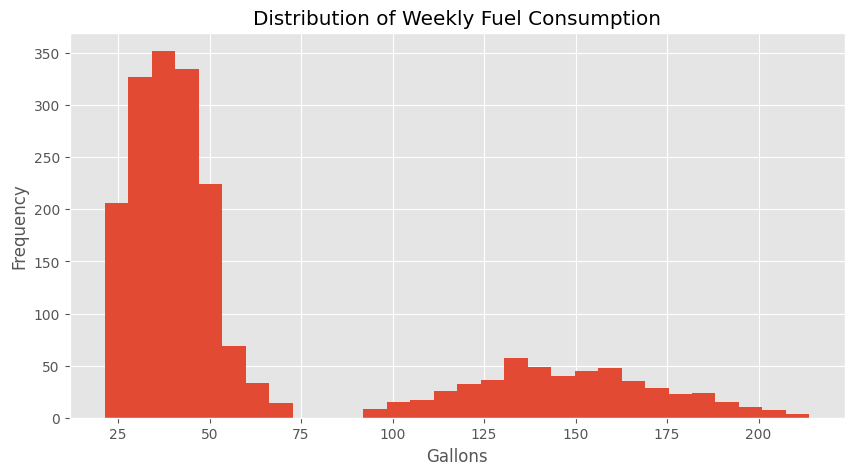

In [79]:
plt.figure(figsize=(10,5))

plt.hist(fuel["gallons"], bins=30)

plt.title("Distribution of Weekly Fuel Consumption")

plt.xlabel("Gallons")

plt.ylabel("Frequency")

plt.show()

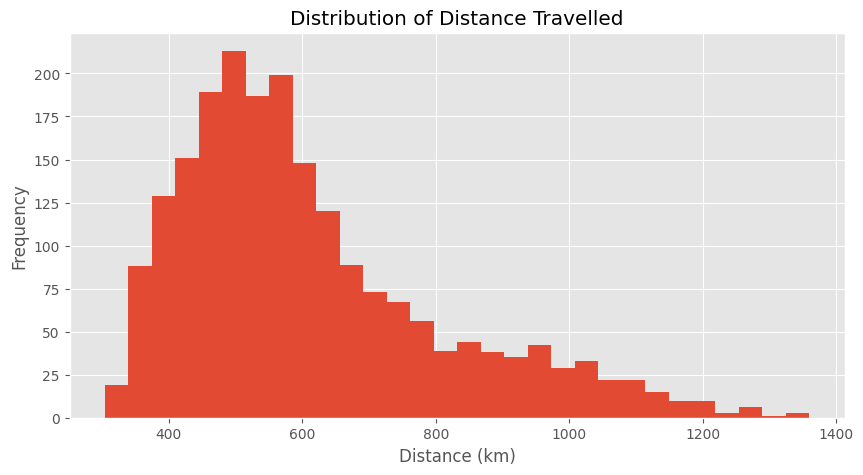

In [80]:
plt.figure(figsize=(10,5))

plt.hist(fuel["distance_km"], bins=30)

plt.title("Distribution of Distance Travelled")

plt.xlabel("Distance (km)")

plt.ylabel("Frequency")

plt.show()

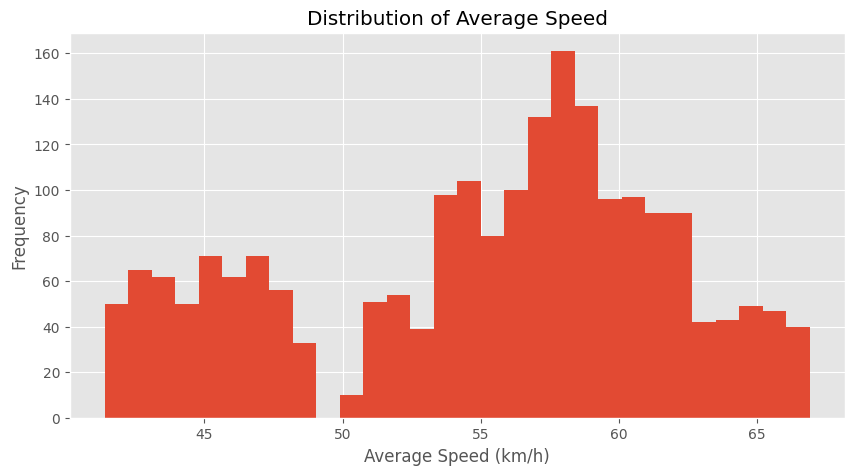

In [81]:
plt.figure(figsize=(10,5))

plt.hist(fuel["avg_speed_kph"], bins=30)

plt.title("Distribution of Average Speed")

plt.xlabel("Average Speed (km/h)")

plt.ylabel("Frequency")

plt.show()

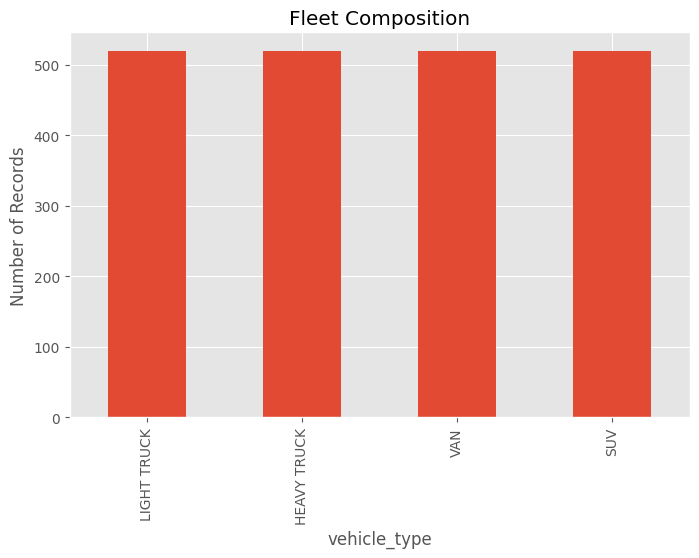

In [82]:
plt.figure(figsize=(8,5))

fuel["vehicle_type"].value_counts().plot(kind="bar")

plt.title("Fleet Composition")

plt.ylabel("Number of Records")

plt.show()

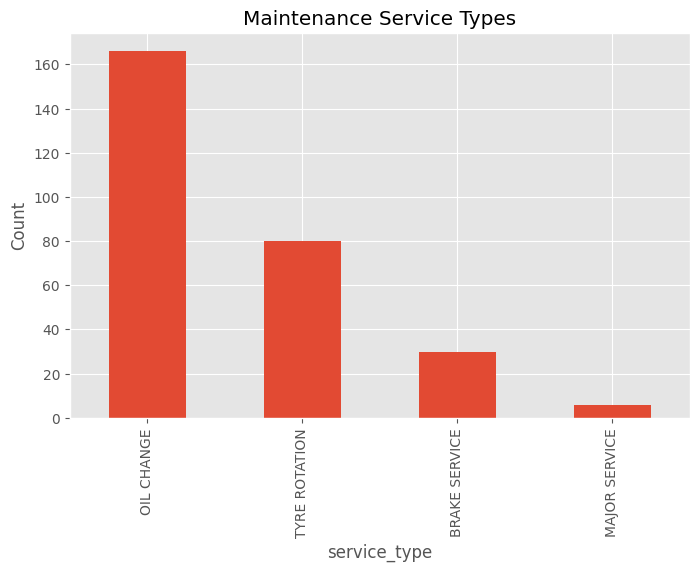

In [83]:
plt.figure(figsize=(8,5))

maintenance["service_type"].value_counts().plot(kind="bar")

plt.title("Maintenance Service Types")

plt.ylabel("Count")

plt.show()

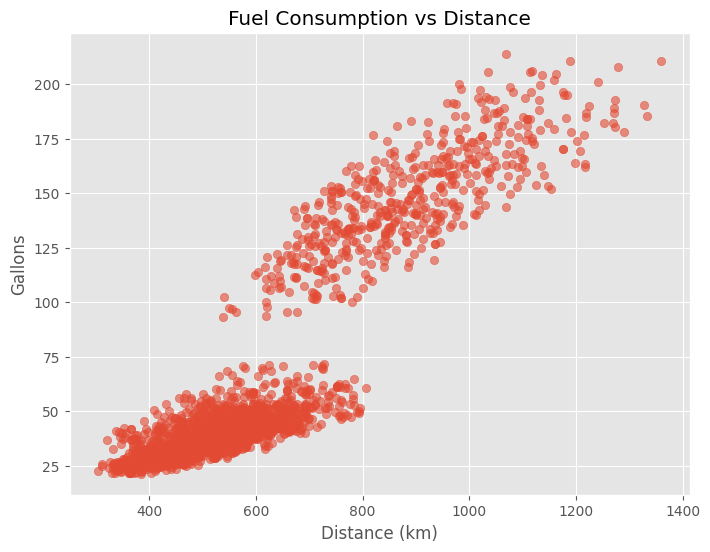

In [84]:
plt.figure(figsize=(8,6))

plt.scatter(
    fuel["distance_km"],
    fuel["gallons"],
    alpha=.6
)

plt.xlabel("Distance (km)")
plt.ylabel("Gallons")

plt.title("Fuel Consumption vs Distance")

plt.show()

<Figure size 1000x600 with 0 Axes>

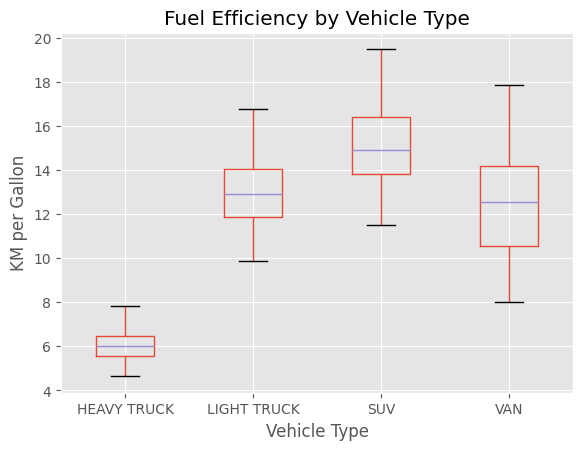

In [85]:
plt.figure(figsize=(10,6))

fuel.boxplot(
    column="km_per_gallon",
    by="vehicle_type"
)

plt.title("Fuel Efficiency by Vehicle Type")

plt.suptitle("")

plt.xlabel("Vehicle Type")

plt.ylabel("KM per Gallon")

plt.show()

<Figure size 1000x600 with 0 Axes>

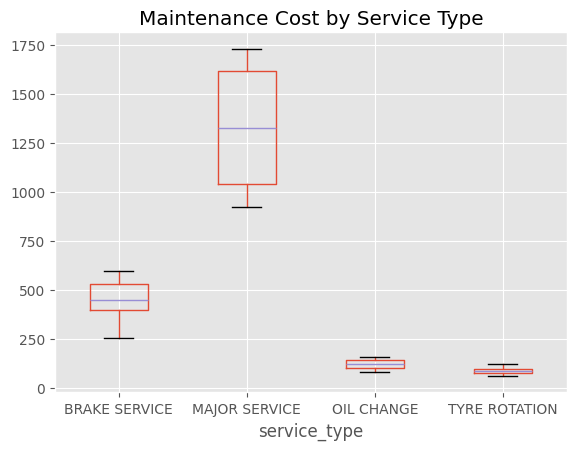

In [86]:
plt.figure(figsize=(10,6))

maintenance.boxplot(
    column="cost_usd",
    by="service_type"
)

plt.suptitle("")

plt.title("Maintenance Cost by Service Type")

plt.show()

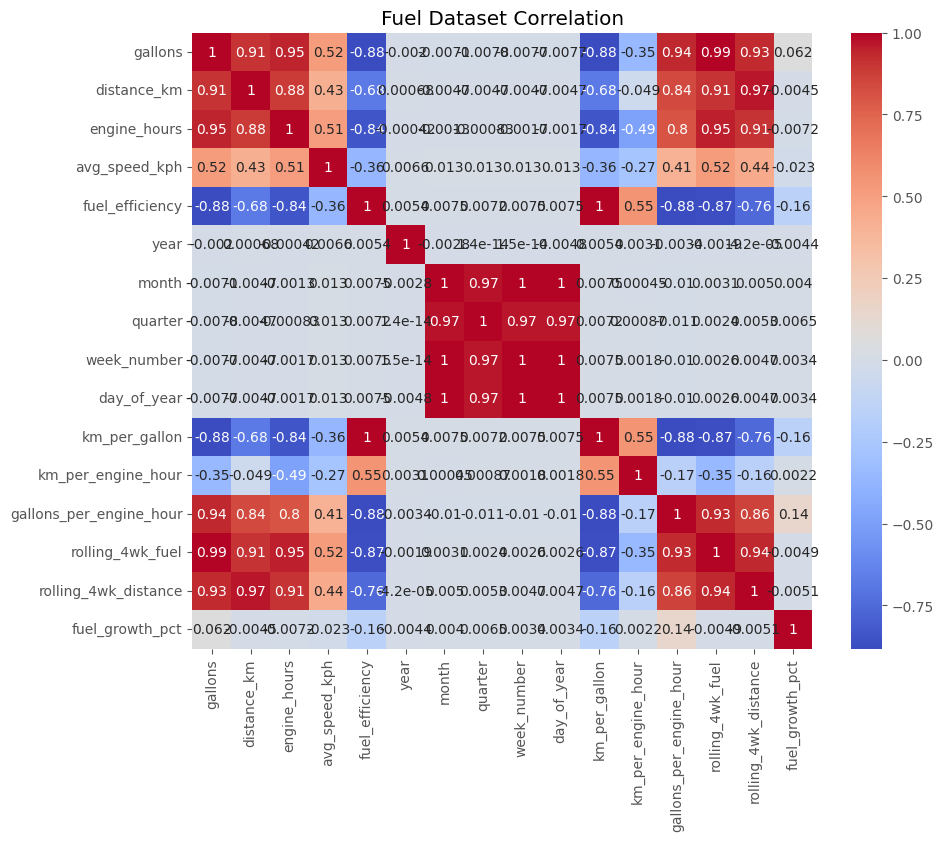

In [87]:
plt.figure(figsize=(10,8))

corr = fuel.select_dtypes(include="number").corr()

import seaborn as sns

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Fuel Dataset Correlation")

plt.show()

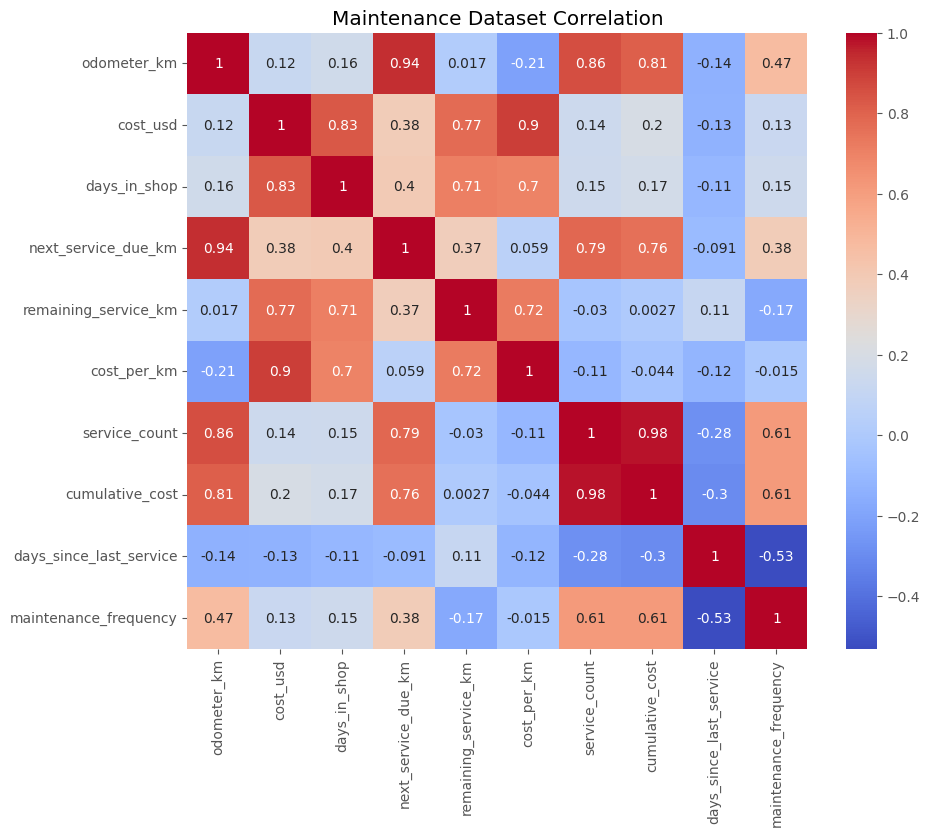

In [88]:
plt.figure(figsize=(10,8))

corr = maintenance.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Maintenance Dataset Correlation")

plt.show()

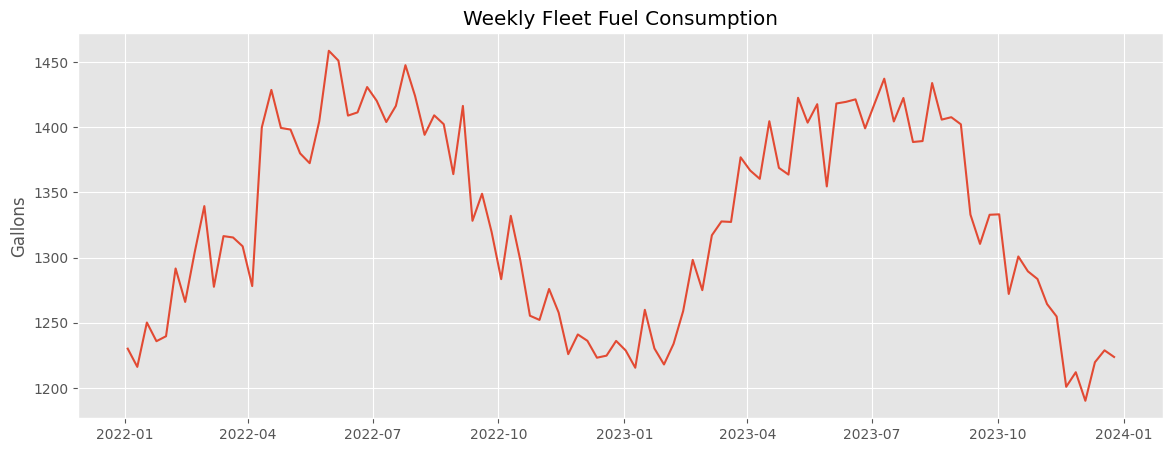

In [89]:
weekly = (
    fuel
    .groupby("week_start")["gallons"]
    .sum()
)

plt.figure(figsize=(14,5))

plt.plot(weekly)

plt.title("Weekly Fleet Fuel Consumption")

plt.ylabel("Gallons")

plt.show()

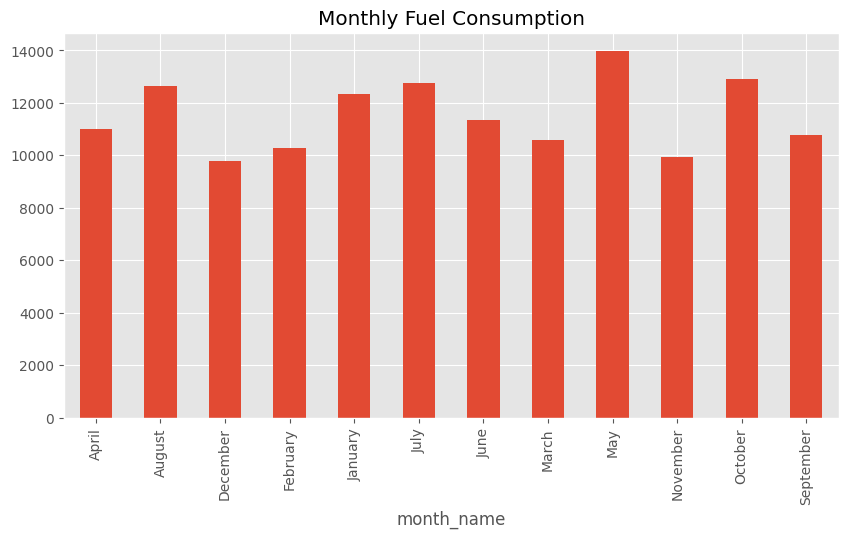

In [90]:
monthly = (
    fuel
    .groupby("month_name")["gallons"]
    .sum()
)

monthly.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Fuel Consumption")

plt.show()

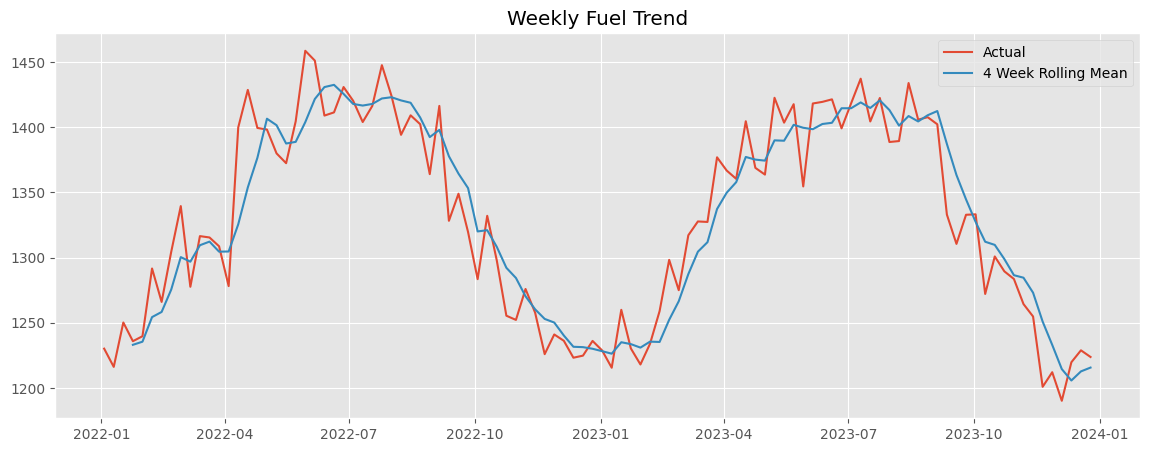

In [91]:
rolling = weekly.rolling(4).mean()

plt.figure(figsize=(14,5))

plt.plot(weekly,label="Actual")

plt.plot(rolling,label="4 Week Rolling Mean")

plt.legend()

plt.title("Weekly Fuel Trend")

plt.show()

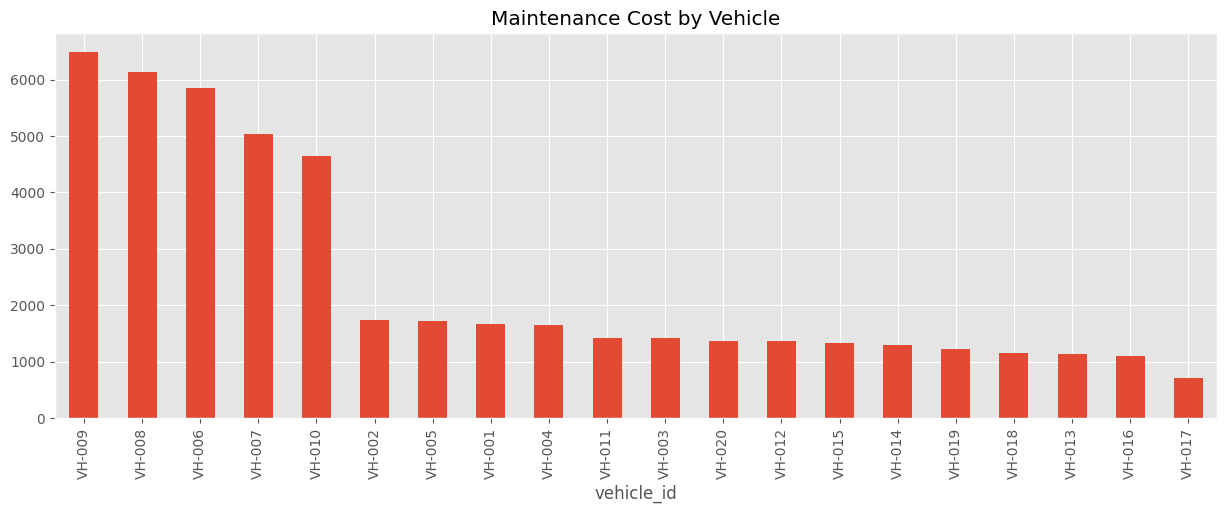

In [92]:
cost = (
    maintenance
    .groupby("vehicle_id")["cost_usd"]
    .sum()
    .sort_values(ascending=False)
)

cost.plot(
    kind="bar",
    figsize=(15,5)
)

plt.title("Maintenance Cost by Vehicle")

plt.show()

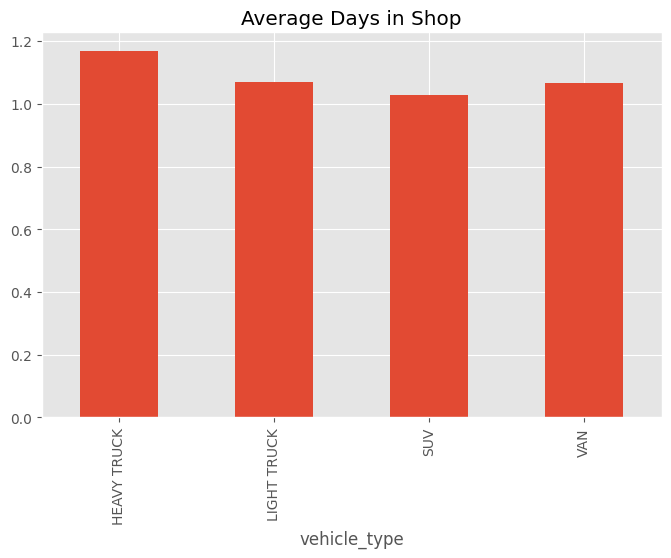

In [93]:
maintenance.groupby(
    "vehicle_type"
)["days_in_shop"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Days in Shop")

plt.show()

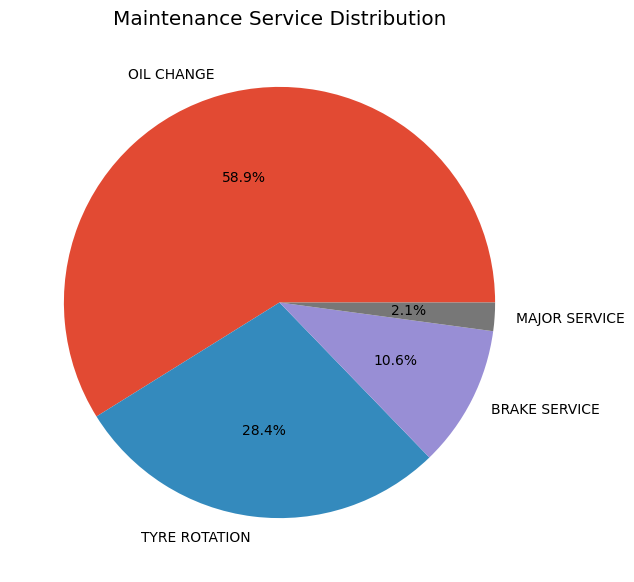

In [94]:
maintenance["service_type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")

plt.title("Maintenance Service Distribution")

plt.show()

In [95]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"""
Total Vehicles               : {fuel['vehicle_id'].nunique()}

Total Fuel Used              : {fuel['gallons'].sum():,.2f} gallons

Average Weekly Fuel          : {fuel['gallons'].mean():,.2f} gallons

Average Fuel Efficiency      : {fuel['km_per_gallon'].mean():.2f} km/gallon

Total Maintenance Cost       : ${maintenance['cost_usd'].sum():,.2f}

Average Maintenance Cost     : ${maintenance['cost_usd'].mean():,.2f}

Average Days in Shop         : {maintenance['days_in_shop'].mean():.2f}

Most Common Service          : {maintenance['service_type'].mode()[0]}

Highest Fuel Vehicle         : {fuel.groupby('vehicle_id')['gallons'].sum().idxmax()}

Highest Maintenance Vehicle  : {maintenance.groupby('vehicle_id')['cost_usd'].sum().idxmax()}
""")

BUSINESS INSIGHTS

Total Vehicles               : 20

Total Fuel Used              : 138,301.19 gallons

Average Weekly Fuel          : 66.49 gallons

Average Fuel Efficiency      : 11.65 km/gallon

Total Maintenance Cost       : $48,521.95

Average Maintenance Cost     : $172.06

Average Days in Shop         : 1.11

Most Common Service          : OIL CHANGE

Highest Fuel Vehicle         : VH-009

Highest Maintenance Vehicle  : VH-009



In [96]:
# =====================================================
# Dashboard Summary Data
# =====================================================

weekly_fuel = (
    fuel.groupby("week_start")["gallons"]
    .sum()
    .reset_index()
)

fuel_vehicle = (
    fuel.groupby("vehicle_id")["gallons"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

vehicle_type = (
    fuel.groupby("vehicle_type")["gallons"]
    .sum()
    .reset_index()
)

fuel_type = (
    fuel.groupby("fuel_type")["gallons"]
    .sum()
    .reset_index()
)

maintenance_cost = (
    maintenance.groupby("vehicle_id")["cost_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

service_type = (
    maintenance.groupby("service_type")
    .size()
    .reset_index(name="Count")
)

days_shop = (
    maintenance.groupby("vehicle_type")["days_in_shop"]
    .mean()
    .reset_index()
)

In [97]:
# =====================================================
# Fleet Executive Dashboard
# =====================================================

fig = make_subplots(

    rows=4,
    cols=2,

    subplot_titles=(

        "Weekly Fuel Trend",

        "Top Fuel Consumers",

        "Fuel Consumption by Vehicle Type",

        "Fuel Type Distribution",

        "Maintenance Cost by Vehicle",

        "Maintenance Service Distribution",

        "Average Days in Shop",

        "Fuel Efficiency Distribution"

    ),

    specs=[
        [{"type":"scatter"},{"type":"bar"}],
        [{"type":"bar"},{"type":"pie"}],
        [{"type":"bar"},{"type":"bar"}],
        [{"type":"bar"},{"type":"histogram"}]
    ],

    vertical_spacing=0.12,
    horizontal_spacing=0.10

)

In [98]:
fig.add_trace(

    go.Scatter(

        x=weekly_fuel["week_start"],

        y=weekly_fuel["gallons"],

        mode="lines",

        name="Fuel"

    ),

    row=1,
    col=1

)

In [99]:
fig.add_trace(

    go.Bar(

        x=fuel_vehicle["vehicle_id"],

        y=fuel_vehicle["gallons"],

        name="Fuel"

    ),

    row=1,
    col=2

)

In [100]:
fig.add_trace(

    go.Bar(

        x=vehicle_type["vehicle_type"],

        y=vehicle_type["gallons"]

    ),

    row=2,
    col=1

)

In [101]:
fig.add_trace(

    go.Pie(

        labels=fuel_type["fuel_type"],

        values=fuel_type["gallons"]

    ),

    row=2,
    col=2

)

In [102]:
fig.add_trace(

    go.Bar(

        x=maintenance_cost["vehicle_id"],

        y=maintenance_cost["cost_usd"]

    ),

    row=3,
    col=1

)

In [103]:
fig.add_trace(

    go.Bar(

        x=service_type["service_type"],

        y=service_type["Count"]

    ),

    row=3,
    col=2

)

In [104]:
fig.add_trace(

    go.Bar(

        x=days_shop["vehicle_type"],

        y=days_shop["days_in_shop"]

    ),

    row=4,
    col=1

)

In [105]:
fig.add_trace(

    go.Histogram(

        x=fuel["km_per_gallon"],

        nbinsx=20

    ),

    row=4,
    col=2

)

In [106]:
import plotly.graph_objects as go
fig = go.Figure()

fig.update_layout(
    height=1400,
    width=1600,
    template="plotly_dark",
    title={
        "text": "Fleet Analytics Executive Dashboard",
        "x": 0.5,
        "font": {
            "size": 28
        }
    },  # <--- Added missing comma here
    showlegend=False
)

In [107]:
# =====================================================
# Save Dashboard
# =====================================================

from pathlib import Path

dashboard_folder = Path("dashboard")

dashboard_folder.mkdir(exist_ok=True)

fig.write_html(
    dashboard_folder / "fleet_dashboard.html"
)

print("Dashboard saved successfully.")

Dashboard saved successfully.
